# Results

In [33]:
PROBLEMS_FILE = './data/problems.json'
SOLUTIONS_FILE = './data/solutions.json'
EVALUATIONS_FILE = './data/evaluations.json'

In [34]:
from src import read_json

problems = read_json(PROBLEMS_FILE)
solutions = read_json(SOLUTIONS_FILE)
evaluations = read_json(EVALUATIONS_FILE)

## FP2MP-Eval

In [35]:
import pandas as pd

data = []

for evaluation_id, evaluation_data in evaluations.items():
    solution_id = evaluation_data['solution_id']
    solution_baseline = solutions[solution_id]['baseline']
    if 'fp2mp' not in solution_baseline:
        continue
    problem_id = solutions[solution_id]['problem_id']
    for evaluation in evaluation_data['content']:
        for criterion in evaluation.keys():
            score = evaluation[criterion]['score']
            data.append({
                'baseline': solution_baseline,
                'problem_id': problem_id,
                'criterion': criterion,
                'score': score
            })

df = pd.DataFrame(data)
df

,baseline,problem_id,criterion,score
0,fp2mp,82fbc85fcfff5fe780b66e3914768cd3,framing,5
1,fp2mp,82fbc85fcfff5fe780b66e3914768cd3,decomposition,4
2,fp2mp,82fbc85fcfff5fe780b66e3914768cd3,diversity,3
3,fp2mp,82fbc85fcfff5fe780b66e3914768cd3,coherence,4
4,fp2mp,82fbc85fcfff5fe780b66e3914768cd3,justification,4
...,...,...,...,...
11995,fp2mp-wo-tools,72fd7da3ab53563a88b22ec77cad6aad,coherence,4
11996,fp2mp-wo-tools,72fd7da3ab53563a88b22ec77cad6aad,justification,4
11997,fp2mp-wo-tools,72fd7da3ab53563a88b22ec77cad6aad,uncertainty_handling,5
11998,fp2mp-wo-tools,72fd7da3ab53563a88b22ec77cad6aad,knowledge_integration,4


In [36]:
df.groupby(['baseline', 'criterion'])['score'].agg(lambda s : f'{s.mean().round(2)} ± {s.std().round(2)}').unstack(level=0)

baseline,fp2mp,fp2mp-wo-blackboard,fp2mp-wo-critic,fp2mp-wo-redi,fp2mp-wo-tools
criterion,,,,,
coherence,4.39 ± 0.52,4.3 ± 0.46,4.46 ± 0.51,4.4 ± 0.5,4.46 ± 0.5
decomposition,4.15 ± 0.47,4.09 ± 0.41,4.18 ± 0.47,4.0 ± 0.55,4.22 ± 0.44
diversity,3.55 ± 0.54,3.69 ± 0.52,3.62 ± 0.53,3.5 ± 0.56,3.86 ± 0.4
framing,4.58 ± 0.49,4.45 ± 0.52,4.6 ± 0.53,4.52 ± 0.57,4.58 ± 0.49
justification,4.36 ± 0.56,4.17 ± 0.49,4.38 ± 0.59,4.31 ± 0.58,4.25 ± 0.47
knowledge_integration,3.77 ± 0.55,3.94 ± 0.45,3.79 ± 0.53,3.69 ± 0.64,4.24 ± 0.47
metacognition,5.0 ± 0.0,5.0 ± 0.0,5.0 ± 0.0,5.0 ± 0.0,4.99 ± 0.11
uncertainty_handling,4.74 ± 0.45,4.71 ± 0.46,4.81 ± 0.39,4.77 ± 0.43,4.66 ± 0.47


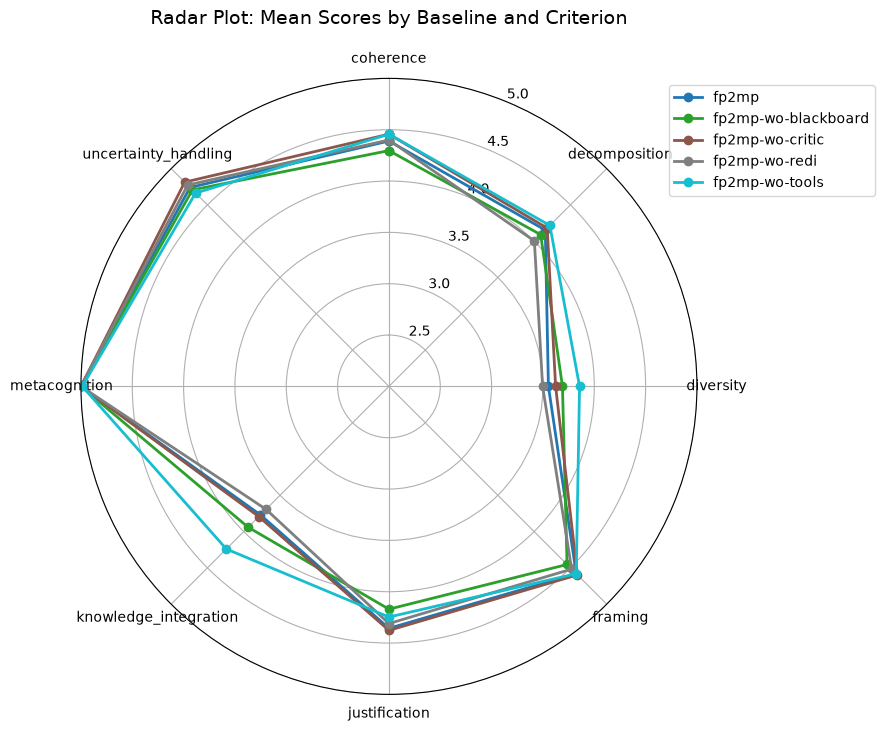

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Предположим, что ваш DataFrame после groupby и unstack выглядит так:
# df_radar = df.groupby(['baseline', 'criterion'])['score'].agg('mean').unstack(level=0)

# Пример данных (замените на свои)
# df_radar = ... 

def plot_radar(df_radar):
    """
    Построение радарного графика
    
    Parameters:
    df_radar: DataFrame со столбцами = baseline, индексами = criterion
    """
    
    # Получаем количество критериев (направлений радара)
    criteria = df_radar.index.tolist()
    num_vars = len(criteria)
    
    # Углы для каждой оси радара
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Замыкаем график (добавляем первую точку в конец)
    angles += angles[:1]
    
    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Цветовая схема для разных baseline
    colors = plt.cm.tab10(np.linspace(0, 1, len(df_radar.columns)))
    
    # Рисуем линию для каждого baseline
    for i, baseline in enumerate(df_radar.columns):
        values = df_radar[baseline].values.flatten().tolist()
        values += values[:1]  # замыкаем значения
        
        ax.plot(angles, values, 'o-', linewidth=2, 
                label=baseline, color=colors[i])
        # ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    # Настройка осей
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(criteria, fontsize=10)
    ax.set_ylim(2, 5)
    
    # Диапазон значений на осях (настройте под свои данные)
    # ax.set_ylim(0, max(df_radar.max().max(), 1))
    
    # Добавляем сетку
    ax.set_theta_offset(pi / 2)   # поворот, чтобы первая ось была сверху
    ax.set_theta_direction(-1)    # по часовой стрелке
    
    # Легенда
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    # Заголовок
    plt.title('Radar Plot: Mean Scores by Baseline and Criterion', 
              size=14, pad=20)
    
    return fig, ax

# Использование:
df_radar = df.groupby(['baseline', 'criterion'])['score'].agg('mean').unstack(level=0)
fig, ax = plot_radar(df_radar)
plt.show()

In [38]:
df.groupby(['baseline']).agg({'score':lambda s : f'{s.mean().round(2)} ± {s.std().round(2)}'}).transpose()

baseline,fp2mp,fp2mp-wo-blackboard,fp2mp-wo-critic,fp2mp-wo-redi,fp2mp-wo-tools
score,4.32 ± 0.66,4.29 ± 0.59,4.36 ± 0.65,4.27 ± 0.71,4.41 ± 0.54
